# Visualizing the shape of a conversation

Conversations move.  A discussion drifts from topic to topic, doubles back on
itself, and takes sharp turns when a new speaker chimes in.  In this tutorial
we'll make that motion visible: we'll take a real Reddit conversation, embed a
sliding window of its utterances with a sentence-embedding model, and use
HyperTools to draw the conversation as a sequence of utterance trajectories
through meaning space -- colored by who is speaking, and animated so that each
utterance draws itself into the scene, one at a time.

This tutorial uses two extra libraries that are *not* installed with
HyperTools.  You can install them by running:

```
%pip install convokit sentence-transformers
```

(The GIF-conversion step at the end also uses [ffmpeg](https://ffmpeg.org), if
it's available on your system.)

In [1]:
%matplotlib inline
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['HF_HUB_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import warnings
warnings.filterwarnings('ignore')

import random

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image

from convokit import Corpus, download
from sentence_transformers import SentenceTransformer

import hypertools as hyp

## Downloading a corpus of Reddit conversations

[ConvoKit](https://convokit.cornell.edu) provides easy access to dozens of
conversational datasets.  We'll use the `reddit-corpus-small` corpus, which
contains posts and comment threads sampled from 100 highly active
subreddits.

In [2]:
corpus = Corpus(filename=download('reddit-corpus-small'))
corpus.meta

Dataset already exists at /Users/jmanning/.convokit/saved-corpora/reddit-corpus-small


ConvoKitMeta({'subreddit': 'reddit-corpus-small', 'num_posts': 8286, 'num_comments': 288846, 'num_user': 119889})

## Choosing a conversation

We'll pick a conversation at random (seeded for reproducibility) from among
the conversations with at least 10 "usable" utterances -- i.e., utterances
whose text hasn't been deleted or removed.  Utterances are taken in
chronological order, treating the comment thread as one unfolding
conversation.

In [3]:
MIN_UTTERANCES = 10

def usable_utterances(conversation):
    """Chronologically-ordered utterances with non-empty, non-deleted text."""
    utterances = conversation.get_chronological_utterance_list()
    return [u for u in utterances
            if u.text and u.text.strip()
            and u.text.strip() not in ('[deleted]', '[removed]')]

candidates = [c for c in corpus.iter_conversations()
              if len(usable_utterances(c)) >= MIN_UTTERANCES]
print(f'conversations with >= {MIN_UTTERANCES} usable utterances: {len(candidates)}')

random.seed(25)
conversation = random.choice(candidates)
utterances = usable_utterances(conversation)
speakers = [u.speaker.id for u in utterances]
texts = [u.text.strip() for u in utterances]

print(f"\ntitle: {conversation.meta['title']}")
print(f"subreddit: r/{conversation.meta['subreddit']}")
print(f'utterances: {len(utterances)}; speakers: {len(set(speakers))}')
print('\nopening exchange:')
for u in utterances[:4]:
    print(f'  [{u.speaker.id}] {u.text.strip()[:90]}...')

conversations with >= 10 usable utterances: 7773

title: Biome Chooser - Savanna
subreddit: r/Minecraft
utterances: 26; speakers: 9

opening exchange:
  [Camcamcam753] u/Axoladdy suggested [Baobab trees](https://www.reddit.com/r/minecraftsuggestions/comments...
  [Axoladdy] #AYYYYY...
  [Camcamcam753] #CONGRATULATIONS DUDE...
  [TurinTuramber] Hopefully these trees are a new woodtype altogether tho....


## Embedding the conversation with a sliding window

A single utterance can be short and noisy ("lol", "this"), so instead of
embedding utterances one at a time we'll slide a window of 3 consecutive
utterances along the conversation, concatenate the text inside each window,
and embed it with
[`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2),
a compact sentence-BERT model.  Each window embedding captures the local
"state" of the conversation, and because adjacent windows share two
utterances, consecutive states change smoothly -- perfect for drawing
trajectories.

Each window *belongs to* the speaker of its final utterance: that's the
person who most recently moved the conversation to where it is now.

In [4]:
WINDOW_LENGTH = 3

n_windows = len(texts) - WINDOW_LENGTH + 1
window_texts = [' '.join(texts[i:i + WINDOW_LENGTH]) for i in range(n_windows)]
window_speakers = [speakers[i + WINDOW_LENGTH - 1] for i in range(n_windows)]

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
window_embeddings = model.encode(window_texts, show_progress_bar=False)
window_embeddings.shape

(24, 384)

## One trajectory per utterance

Next we build one small array per utterance, containing the sliding-window
embeddings belonging to that utterance.  Under the final-utterance rule each
utterance owns exactly one window -- a single point, which can't be drawn as
a line -- so we merge in the preceding window as well.  Each utterance thus
becomes a short two-point trajectory, from "the conversation just before this
utterance" to "the conversation once it lands."  (The very first window has
no predecessor; it serves as the anchor point of the first utterance's
array.)

To color the utterances we assign each *speaker* a fixed color, so every
utterance by the same speaker is drawn in the same color.

In [5]:
utterance_arrays = [window_embeddings[i - 1:i + 1] for i in range(1, n_windows)]
utterance_speakers = [window_speakers[i] for i in range(1, n_windows)]

speaker_names = sorted(set(window_speakers), key=window_speakers.index)
palette = sns.color_palette('hls', len(speaker_names))
speaker_color = dict(zip(speaker_names, palette))
utterance_colors = [speaker_color[s] for s in utterance_speakers]

print(f'{len(utterance_arrays)} utterance trajectories '
      f'across {len(speaker_names)} speakers')
print('rows per utterance array:', [a.shape[0] for a in utterance_arrays])

23 utterance trajectories across 9 speakers
rows per utterance array: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


## The static shape of the conversation

HyperTools reduces the 384-dimensional window embeddings to 3D and draws each
utterance as its own short line, colored by its speaker.  The utterances are
*not* connected to each other -- each one is a separate stroke -- but because
consecutive windows overlap, the strokes trace out one continuous-looking
path through meaning space.

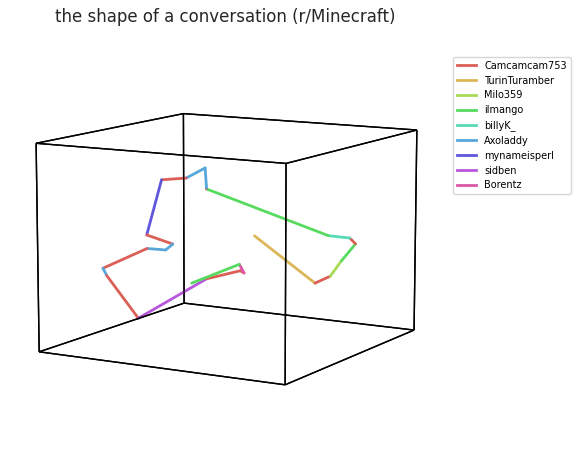

In [6]:
geo = hyp.plot(utterance_arrays, '-', color=utterance_colors, linewidth=2,
               show=False,
               title=f"the shape of a conversation (r/{conversation.meta['subreddit']})")

handles = [plt.Line2D([0], [0], color=speaker_color[s], lw=2)
           for s in speaker_names]
geo.ax.legend(handles, speaker_names, loc='upper left',
              bbox_to_anchor=(1.02, 0.95), fontsize=7)
geo.fig

Each color is one speaker; each stroke is one utterance.  Runs of the same
color show a speaker holding the floor; color changes mark hand-offs between
speakers.

## Watching the conversation unfold

Now for the fun part.  HyperTools' `animate='serial'` mode plays the datasets
back *in list order*: the first utterance grows point-by-point into place;
then the second grows while the first stays fixed; and so on until the whole
conversation has assembled itself -- all while the camera slowly orbits the
scene (`rotations=3` over a 30-second animation).  Utterances are never
connected to each other; each new stroke simply appears where the
conversation went next.

We'll save the animation as an MP4 (compact and fast to render), then use
ffmpeg to convert it into a GIF for inline display.

In [7]:
geo = hyp.plot(utterance_arrays, '-', color=utterance_colors,
               animate='serial', duration=30, rotations=3, frame_rate=20,
               zoom=2.5, linewidth=2,
               save_path='conversation_serial.mp4', show=False)

size_mb = os.path.getsize('conversation_serial.mp4') / 1e6
print(f'conversation_serial.mp4: {size_mb:0.1f} MB')

conversation_serial.mp4: 6.6 MB


conversation_serial.gif: 5.4 MB


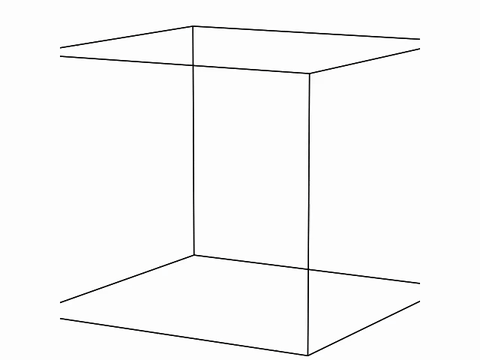

In [8]:
import shutil
import subprocess

if shutil.which('ffmpeg'):
    filters = ('fps=12,scale=480:-1:flags=lanczos,split [a][b]; '
               '[a] palettegen [p]; [b][p] paletteuse')
    subprocess.run(['ffmpeg', '-y', '-i', 'conversation_serial.mp4',
                    '-vf', filters, 'conversation_serial.gif'],
                   check=True, capture_output=True)
    os.remove('conversation_serial.mp4')
    size_mb = os.path.getsize('conversation_serial.gif') / 1e6
    print(f'conversation_serial.gif: {size_mb:0.1f} MB')

Image('conversation_serial.gif')

## Next steps

Try a longer conversation (raise `MIN_UTTERANCES`), a different window length,
or another ConvoKit corpus entirely (`movie-corpus`,
`supreme-court-arguments`, ...).  You could also compare *several*
conversations at once by passing multiple trajectories to `hyp.plot`, or use
`hyp.align` to map different conversations into a shared space.